# Regressão

## Imports

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Gym Exercise

In [1]:
path = "C:/Users/bianc/OneDrive/Documents/1-Estudos/2-DNC/1-Data Science/1-Material/Materis9-Modelos_de_Classificacao_Regressao/Regressao/Regressao-main/Datasets/gym_members_exercise_tracking.csv"

In [2]:
path

'C:/Users/bianc/OneDrive/Documents/1-Estudos/2-DNC/1-Data Science/1-Material/Materis9-Modelos_de_Classificacao_Regressao/Regressao/Regressao-main/Datasets/gym_members_exercise_tracking.csv'

In [5]:
df_gym = pd.read_csv(path + "/gym_members_exercise_tracking.csv")

In [6]:
df_gym.shape

(973, 15)

In [7]:
df_gym.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


<Axes: xlabel='Session_Duration (hours)', ylabel='Calories_Burned'>

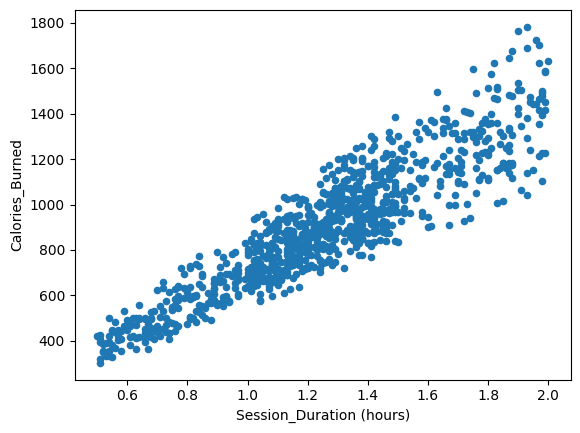

In [8]:
df_gym.plot(x="Session_Duration (hours)", y="Calories_Burned", kind="scatter")

## Separando Atributos e Target

In [9]:
X = df_gym[["Session_Duration (hours)"]]
y = df_gym[["Calories_Burned"]]

## Criando uma Regressão Linear Simples

In [10]:
from sklearn.linear_model import LinearRegression

In [11]:
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
pred = model.predict(X)

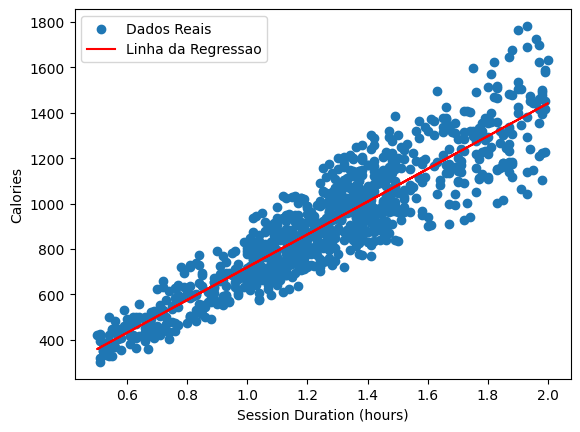

In [13]:
plt.scatter(x=X["Session_Duration (hours)"], y=y, label="Dados Reais")
plt.plot(X["Session_Duration (hours)"], pred, label="Linha da Regressao", color="red")

plt.ylabel("Calories")
plt.xlabel("Session Duration (hours)")
plt.legend()
plt.show()

In [14]:
residuals = y - pred

In [16]:
residuals

,Calories_Burned
0,94.628092
1,-53.875362
2,-122.736019
3,107.592709
4,95.503409
...,...
968,232.242414
969,265.381757
970,-311.025489
971,90.481841


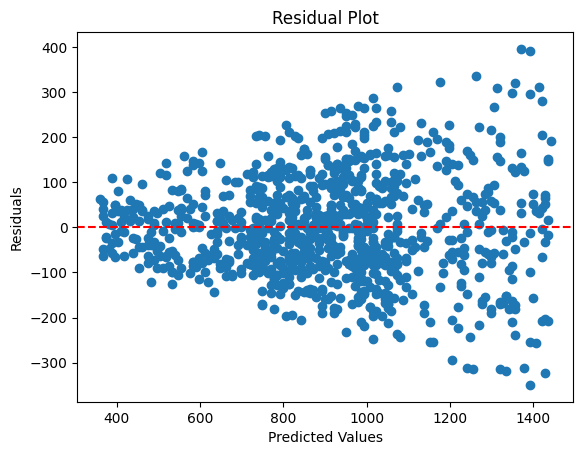

In [15]:
plt.scatter(pred, residuals)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Text(0.5, 1.0, 'Pred x Target')

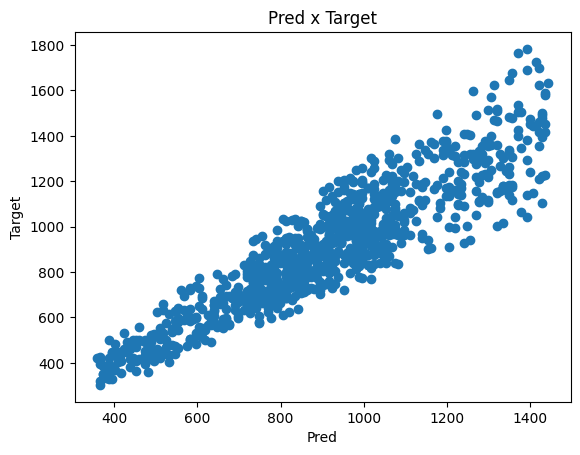

In [17]:
plt.scatter(pred, y)
plt.xlabel("Pred")
plt.ylabel("Target")
plt.title("Pred x Target")

## Separando os dados em Treino e Teste

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X = df_gym.drop("Calories_Burned", axis=1)
y = df_gym["Calories_Burned"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [21]:
X_train.shape

(778, 14)

In [22]:
X_test.shape

(195, 14)

In [23]:
X_train.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
967,20,Male,55.0,1.60,172,168,67,1.12,Yoga,24.0,3.2,4,2,21.48
365,39,Female,60.6,1.65,162,167,63,0.92,HIIT,27.6,1.7,3,1,22.26
559,54,Female,75.6,1.72,194,154,60,0.97,Cardio,26.4,1.9,3,1,25.55
33,24,Female,58.9,1.51,187,157,68,1.04,Cardio,31.7,2.5,2,1,25.83
31,20,Female,65.4,1.52,185,127,50,1.03,Yoga,28.0,2.2,4,2,28.31


## Tratando atributos categóricos

In [24]:
X_train["Workout_Type"].value_counts()

Workout_Type
Strength    211
Cardio      209
HIIT        179
Yoga        179
Name: count, dtype: int64

In [25]:
from sklearn.preprocessing import OneHotEncoder

In [26]:
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
encoder.fit(X_train[["Workout_Type", "Gender"]])

X_train_categorical_columns = encoder.transform(X_train[["Workout_Type", "Gender"]])
X_test_categorical_columns = encoder.transform(X_test[["Workout_Type", "Gender"]])

In [27]:
X_train = pd.concat([X_train.drop(["Workout_Type", "Gender"], axis=1), X_train_categorical_columns], axis=1)

In [28]:
X_test = pd.concat([X_test.drop(["Workout_Type", "Gender"], axis=1), X_test_categorical_columns], axis=1)

### Trinando e realizando Predict

In [31]:
from sklearn.metrics import mean_absolute_error

In [32]:
model = LinearRegression()
model.fit(X_train[["Session_Duration (hours)"]], y_train)

y_pred = model.predict(X_test[["Session_Duration (hours)"]])
mae = mean_absolute_error(y_test, y_pred)
mae

95.03480033445553

## Avaliando as predições

In [33]:
residuals = y_test - y_pred

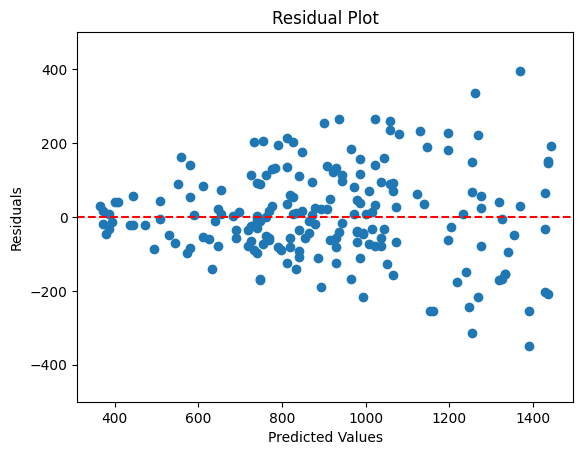

In [34]:
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.ylim((-500, 500))
plt.show()

## Regressão Linear Múltipla

In [35]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mae

30.270139845320745

In [36]:
residuals = y_test - y_pred

In [37]:
residuals.abs().mean()

np.float64(30.270139845320745)

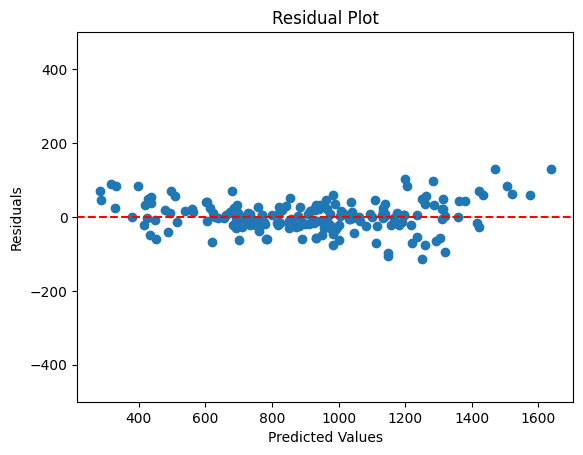

In [38]:
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.ylim((-500, 500))
plt.show()